### Evaluation Charts

Visualize performance comparison between Pandas Polars and PySpark on 3 key metrics:
- Execution time (s)
- Memory Usage (MB)
- CPU usage (%)
- Throughput (records/s)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

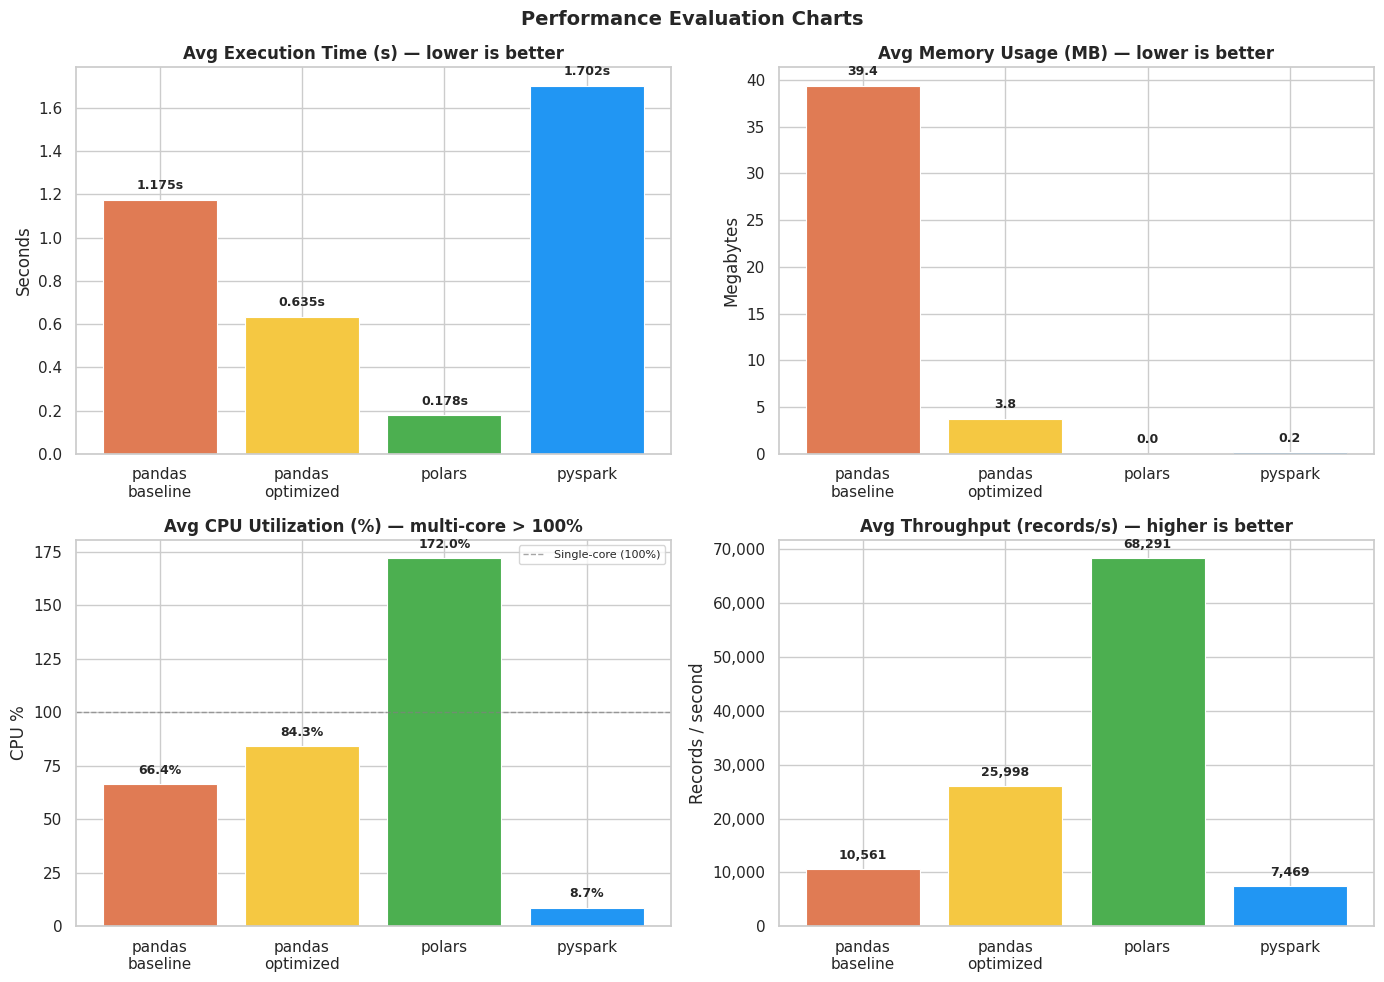

In [2]:
CSV_RESULTS = 'performance_after.csv'

df_raw = pd.read_csv(CSV_RESULTS)

df_avg = (
    df_raw
    .groupby('method', sort=False)
    .agg(
        time_sec                  = ('time_sec',    'mean'),
        memory_mb                 = ('memory_mb',   'mean'),
        cpu_percent               = ('cpu_%',       'mean'),
        throughput_records_per_sec= ('throughput',  'mean'),
    )
    .reset_index()
)

METHOD_ORDER = ['pandas_baseline', 'pandas_optimized', 'polars', 'pyspark']
df_avg['method'] = pd.Categorical(df_avg['method'], categories=METHOD_ORDER, ordered=True)
df_perf = df_avg.sort_values('method').reset_index(drop=True)

METHOD_COLORS = {
    'pandas_baseline':  '#e07b54',
    'pandas_optimized': '#f5c842',
    'polars':           '#4caf50',
    'pyspark':          '#2196f3',
}
methods = df_perf['method'].tolist()
colors  = [METHOD_COLORS[m] for m in methods]
labels  = [m.replace('_', '\n') for m in methods]

sns.set_theme(style='whitegrid', palette='muted')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'Performance Evaluation Charts',
    fontsize=14, fontweight='bold'
)

# Chart 1: Execution Time
ax = axes[0, 0]
bars = ax.bar(labels, df_perf['time_sec'], color=colors, edgecolor='white', linewidth=0.8)
ax.set_title('Avg Execution Time (s) — lower is better', fontweight='bold')
ax.set_ylabel('Seconds')
y_pad = df_perf['time_sec'].max() * 0.02
for bar, val in zip(bars, df_perf['time_sec']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + y_pad,
            f'{val:.3f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Chart 2: Memory Usage
ax = axes[0, 1]
bars = ax.bar(labels, df_perf['memory_mb'], color=colors, edgecolor='white', linewidth=0.8)
ax.set_title('Avg Memory Usage (MB) — lower is better', fontweight='bold')
ax.set_ylabel('Megabytes')
y_pad = df_perf['memory_mb'].max() * 0.02
for bar, val in zip(bars, df_perf['memory_mb']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + y_pad,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Chart 3: CPU Utilization
ax = axes[1, 0]
bars = ax.bar(labels, df_perf['cpu_percent'], color=colors, edgecolor='white', linewidth=0.8)
ax.set_title('Avg CPU Utilization (%) — multi-core > 100%', fontweight='bold')
ax.set_ylabel('CPU %')
if df_perf['cpu_percent'].max() > 100:
    ax.axhline(y=100, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Single-core (100%)')
    ax.legend(fontsize=8)
y_pad = df_perf['cpu_percent'].max() * 0.02
for bar, val in zip(bars, df_perf['cpu_percent']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + y_pad,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Chart 4: Throughput
ax = axes[1, 1]
bars = ax.bar(labels, df_perf['throughput_records_per_sec'], color=colors, edgecolor='white', linewidth=0.8)
ax.set_title('Avg Throughput (records/s) — higher is better', fontweight='bold')
ax.set_ylabel('Records / second')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
y_pad = df_perf['throughput_records_per_sec'].max() * 0.02
for bar, val in zip(bars, df_perf['throughput_records_per_sec']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + y_pad,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('evaluation_charts.png', dpi=150, bbox_inches='tight')
plt.show()